# DOA estimation using MUSIC with a uniform linear array

In [1]:
import numpy as np
import doatools.model as model
import doatools.estimation as estimation
import doatools.plotting as doaplot

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
np.random.seed(128)

# Parameters
wavelength = 1.0 # Normalized wavelength. Recall that d0 = wavelength / 2.
d0 = wavelength / 2
power_source = 1.0
power_noise = 1.0 # SNR = 0 dB
n_snapshots = 100

# Create a 12-element ULA
ula = model.UniformLinearArray(12, d0)

# Place 7 far-field narrow-band sources uniformly between (-pi/4, pi/4)
sources = model.FarField1DSourcePlacement(np.linspace(-np.pi/4, np.pi/4, 5))

# Use the stochastic signal model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(ula.size, power_noise)

# Get the estimated covariance matrix.
_, R = model.get_narrowband_snapshots(ula, sources, wavelength, source_signal, noise_signal,
                                      n_snapshots, return_covariance=True)




## MUSIC estimation

Estimates: [-0.78539816 -0.40142573  0.          0.40142573  0.78539816]
Ground truth: [-0.78539816 -0.39269908  0.          0.39269908  0.78539816]


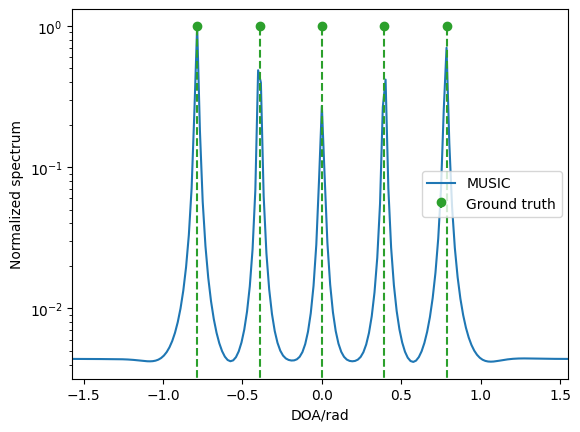

In [ ]:
# Create a MUSIC-based estimator.
grid = estimation.FarField1DSearchGrid()
estimator = estimation.MUSIC(ula, wavelength, grid)
# Get the estimates.
resolved, estimates, sp = estimator.estimate(R, sources.size, return_spectrum=True)
print('MUSIC Estimates: {0}'.format(estimates.locations))
print('Ground truth: {0}'.format(sources.locations))

# Plot the MUSIC-spectrum.
doaplot.plot_spectrum({'MUSIC': sp}, grid, ground_truth=sources, use_log_scale=True);

## ESPRIT estimation

In [8]:
# Create a ESPRIT-based estimator.
estimator = estimation.Esprit1D(wavelength)
# Get the estimates.
resolved, estimates = estimator.estimate(R, sources.size, d0)
print('ESPRIT Estimates: {0}'.format(np.rad2deg(estimates.locations)))
print('Ground truth: {0}'.format(np.rad2deg(sources.locations)))


ESPRIT Estimates: [-4.54802466e+01 -2.24655585e+01 -1.20873102e-03  2.24343493e+01
  4.48215767e+01]
Ground truth: [-45.  -22.5   0.   22.5  45. ]


## Beamforming estimation

In [10]:
grid = estimation.FarField1DSearchGrid()
# MVDR
mvdr = estimation.MVDRBeamformer(ula, wavelength, grid)
resolved, estimates = mvdr.estimate(R, sources.size)
print("MVDR Estimates: {0}".format(np.rad2deg(estimates.locations)))
# Bartlett
bartlett = estimation.BartlettBeamformer(ula, wavelength, grid)
resolved, estimates = bartlett.estimate(R, sources.size)
print("Bartlett Estimates: {0}".format(np.rad2deg(estimates.locations)))

print("Ground truth: {0}".format(np.rad2deg(sources.locations)))


MVDR Estimates: [-45. -23.   0.  23.  45.]
Bartlett Estimates: [-45. -23.   0.  23.  45.]
Ground truth: [-45.  -22.5   0.   22.5  45. ]


## MinNorm Estimates

Min-Norm Estimates: [-45. -23.   0.  23.  45.]


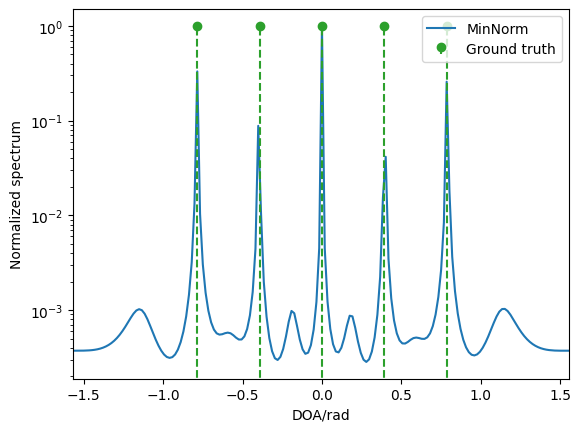

In [13]:
grid = estimation.FarField1DSearchGrid()
mininorm = estimation.MinNorm(ula, wavelength, grid)  
resolved, estimates, sp = mininorm.estimate(R, sources.size,return_spectrum=True)
print("Min-Norm Estimates: {0}".format(np.rad2deg(estimates.locations)))
# Plot the MUSIC-spectrum.
doaplot.plot_spectrum({'MinNorm': sp}, grid, ground_truth=sources, use_log_scale=True);

## Maximum-likelihood Estimates

In [14]:

aml = estimation.AMLEstimator(ula, wavelength)
resolved, estimates = aml.estimate(R, sources.size)
print("Asymptotic maximum-likelihood Estimates: {0}".format(np.rad2deg(estimates.locations)))

cml = estimation.CMLEstimator(ula, wavelength)
resolved, estimates = cml.estimate(R, sources.size)
print("Conditional maximum-likelihood  Estimates: {0}".format(np.rad2deg(estimates.locations)))

wsf = estimation.WSFEstimator(ula, wavelength)
resolved, estimates = wsf.estimate(R, sources.size)
print("Weighted subspace fitting Estimates: {0}".format(np.rad2deg(estimates.locations)))

print("ground truth: {0}".format(np.rad2deg(sources.locations)))

AttributeError: 'int' object has no attribute 'size'